In [1]:
# Install & Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [6]:
#upload data set
from google.colab import files
uploaded = files.upload()

Saving studentAssessment.csv to studentAssessment.csv
Saving studentInfo.csv to studentInfo.csv
Saving studentVle.csv to studentVle.csv


In [8]:
# Load CSV
student_info = pd.read_csv("studentInfo.csv")
student_vle = pd.read_csv("studentVle.csv")
student_assessment = pd.read_csv("studentAssessment.csv")

In [9]:
#shape of student_info
student_info.shape

(32593, 12)

In [10]:
#shape of student_assessment
student_assessment.shape

(173912, 5)

In [11]:
#shape of student_vle
student_vle.shape

(10655280, 6)

In [12]:
#head of student_info
student_info.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [13]:
#head of student_assessment
student_assessment.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [14]:
#head of student_vle
student_vle.head()

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [15]:
# Aggregate studentAssessment — per student
assessment_agg = student_assessment.groupby('id_student').agg(
    avg_score       = ('score', 'mean'),
    max_score       = ('score', 'max'),
    min_score       = ('score', 'min'),
    num_submitted   = ('score', 'count')
).reset_index()

# Aggregate studentVle — per student
vle_agg = student_vle.groupby('id_student').agg(
    total_clicks      = ('sum_click', 'sum'),
    avg_clicks_per_day = ('sum_click', 'mean'),
    active_days       = ('date', 'nunique')
).reset_index()

# Merge all 3
df = student_info.merge(assessment_agg, on='id_student', how='left') \
                 .merge(vle_agg,        on='id_student', how='left')


In [16]:
#shape of merged dataset
df.shape

(32593, 19)

In [17]:
#info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code_module           32593 non-null  object 
 1   code_presentation     32593 non-null  object 
 2   id_student            32593 non-null  int64  
 3   gender                32593 non-null  object 
 4   region                32593 non-null  object 
 5   highest_education     32593 non-null  object 
 6   imd_band              31482 non-null  object 
 7   age_band              32593 non-null  object 
 8   num_of_prev_attempts  32593 non-null  int64  
 9   studied_credits       32593 non-null  int64  
 10  disability            32593 non-null  object 
 11  final_result          32593 non-null  object 
 12  avg_score             26727 non-null  float64
 13  max_score             26727 non-null  float64
 14  min_score             26727 non-null  float64
 15  num_submitted      

In [18]:
#first 5 col
df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,max_score,min_score,num_submitted,total_clicks,avg_clicks_per_day,active_days
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,85.0,78.0,5.0,934.0,4.765306,40.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,70.0,60.0,5.0,1435.0,3.337209,80.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,NaN,NaN,281.0,3.697368,12.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,88.0,71.0,5.0,2158.0,3.254902,123.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,75.0,30.0,5.0,1034.0,2.937500,70.0


In [19]:
#last 5 col
df.tail()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,max_score,min_score,num_submitted,total_clicks,avg_clicks_per_day,active_days
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail,NaN,NaN,NaN,NaN,41.0,2.157895,5.0
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction,88.111111,100.0,72.0,9.0,893.0,3.767932,45.0
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass,76.666667,100.0,60.0,9.0,312.0,2.888889,24.0
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn,91.500000,100.0,83.0,2.0,275.0,4.508197,13.0
32592,GGG,2014J,2684003,F,Yorkshire Region,HE Qualification,50-60%,35-55,0,30,N,Distinction,82.857143,100.0,60.0,7.0,616.0,3.403315,34.0


In [20]:
#unique values
df.nunique()

,0
code_module,7
code_presentation,4
id_student,28785
gender,2
region,13
highest_education,5
imd_band,10
age_band,3
num_of_prev_attempts,7
studied_credits,61


In [21]:
#columns name
df.columns.tolist()

['code_module',
 'code_presentation',
 'id_student',
 'gender',
 'region',
 'highest_education',
 'imd_band',
 'age_band',
 'num_of_prev_attempts',
 'studied_credits',
 'disability',
 'final_result',
 'avg_score',
 'max_score',
 'min_score',
 'num_submitted',
 'total_clicks',
 'avg_clicks_per_day',
 'active_days']

In [22]:
#duplicate
df.duplicated().sum()

np.int64(0)

In [23]:
#missing values
df.isnull().sum()

,0
code_module,0
code_presentation,0
id_student,0
gender,0
region,0
highest_education,0
imd_band,1111
age_band,0
num_of_prev_attempts,0
studied_credits,0


In [24]:
#describe
df.describe().round(2)

,id_student,num_of_prev_attempts,studied_credits,avg_score,max_score,min_score,num_submitted,total_clicks,avg_clicks_per_day,active_days
count,32593.00,32593.00,32593.00,26727.00,26727.00,26727.00,26746.00,29741.00,29741.00,29741.0
mean,706687.67,0.16,79.76,72.83,87.65,53.66,7.74,1620.86,3.30,69.6
std,549167.31,0.48,41.07,15.56,15.86,22.56,4.54,2050.31,1.19,58.1
min,3733.00,0.00,30.00,0.00,0.00,0.00,0.00,1.00,1.00,1.0
25%,508573.00,0.00,60.00,64.80,81.00,40.00,4.00,324.00,2.41,22.0
50%,590310.00,0.00,60.00,75.71,93.00,58.00,7.00,903.00,3.13,55.0
75%,644453.00,0.00,120.00,84.06,100.00,70.00,11.00,2171.00,4.01,104.0
max,2716795.00,6.00,655.00,100.00,100.00,100.00,28.00,28615.00,19.43,286.0


In [25]:
# Categorical — fill with mode
df['imd_band'] = df['imd_band'].fillna(df['imd_band'].mode()[0])

# Assessment scores — fill with median
df['avg_score'] = df['avg_score'].fillna(df['avg_score'].median())
df['max_score'] = df['max_score'].fillna(df['max_score'].median())
df['min_score'] = df['min_score'].fillna(df['min_score'].median())

# Never submitted — fill with 0
df['num_submitted'] = df['num_submitted'].fillna(0)

# Never clicked — fill with 0
df['total_clicks']       = df['total_clicks'].fillna(0)
df['avg_clicks_per_day'] = df['avg_clicks_per_day'].fillna(0)
df['active_days']        = df['active_days'].fillna(0)

# Verify
print("Nulls after treatment:")
print(df.isnull().sum())

Nulls after treatment:
code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
avg_score               0
max_score               0
min_score               0
num_submitted           0
total_clicks            0
avg_clicks_per_day      0
active_days             0
dtype: int64


In [26]:
#skew
import pandas as pd

numerical_cols = ['num_of_prev_attempts', 'studied_credits', 'avg_score',
                  'max_score', 'min_score', 'num_submitted',
                  'total_clicks', 'avg_clicks_per_day', 'active_days']

skew_kurt = pd.DataFrame({
    'Skewness' : df[numerical_cols].skew().round(3),
    'Kurtosis' : df[numerical_cols].kurt().round(3)
})

print(skew_kurt)

                      Skewness  Kurtosis
num_of_prev_attempts     3.808    19.432
studied_credits          1.876     7.738
avg_score               -1.403     3.523
max_score               -2.401     7.848
min_score               -0.756     0.472
num_submitted            0.512    -0.273
total_clicks             3.203    18.126
avg_clicks_per_day       0.255     2.931
active_days              1.028     0.464


In [27]:
# IQR based outlier count
print("\nOutlier counts per column (IQR method):")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)].shape[0]
    print(f"{col:25s} → {outliers} outliers")


Outlier counts per column (IQR method):
num_of_prev_attempts      → 4172 outliers
studied_credits           → 350 outliers
avg_score                 → 1492 outliers
max_score                 → 1987 outliers
min_score                 → 1444 outliers
num_submitted             → 8 outliers
total_clicks              → 2184 outliers
avg_clicks_per_day        → 410 outliers
active_days               → 484 outliers


In [29]:
# Create binary target
df['at_risk'] = df['final_result'].isin(['Withdrawn', 'Fail']).astype(int)

# Check class balance
print(df['at_risk'].value_counts(normalize=True).round(3))

at_risk
1    0.528
0    0.472
Name: proportion, dtype: float64


In [30]:
#VIF: check multicollinearity among numerical features
from statsmodels.stats.outliers_influence import variance_inflation_factor

features = df[numerical_cols].dropna()
vif_data = pd.DataFrame({
    'Feature': numerical_cols,
    'VIF': [variance_inflation_factor(features.values, i)
            for i in range(features.shape[1])]
})
print(vif_data.sort_values('VIF', ascending=False))

                Feature         VIF
2             avg_score  334.204728
3             max_score  183.761006
4             min_score   38.821219
8           active_days    8.862948
7    avg_clicks_per_day    6.437062
5         num_submitted    5.794308
6          total_clicks    5.531874
1       studied_credits    4.421971
0  num_of_prev_attempts    1.160346


In [31]:
# Drop avg_score and max_score — keep only min_score as the score representative
# OR create a composite that captures spread
df['score_range'] = df['max_score'] - df['min_score']

# Updated numerical cols after VIF treatment
numerical_cols = ['num_of_prev_attempts', 'studied_credits', 'min_score',
                  'score_range', 'num_submitted', 'total_clicks',
                  'avg_clicks_per_day', 'active_days']

In [32]:
# Winsorize only for Logistic Regression prep (cap, did't delete rows)
from scipy.stats import mstats

cols_to_winsorize = ['num_of_prev_attempts', 'total_clicks', 'min_score', 'score_range']

df_lr = df.copy()
for col in cols_to_winsorize:
    df_lr[col] = mstats.winsorize(df_lr[col], limits=[0.01, 0.01])

# XGBoost version — use raw df, trees handle outliers naturally
df_xgb = df.copy()

In [33]:
# Log transform highly skewed features to reduce skewness
import numpy as np

high_skew = ['num_of_prev_attempts', 'total_clicks']  # skew > 3

for col in high_skew:
    df_lr[col + '_log'] = np.log1p(df_lr[col])
    df_lr.drop(columns=[col], inplace=True)

In [34]:
# Recheck VIF after transformations (ensure multicollinearity is reduced)
features_clean = df_lr[['num_of_prev_attempts_log', 'studied_credits', 'min_score',
                          'score_range', 'num_submitted', 'total_clicks_log',
                          'avg_clicks_per_day', 'active_days']].dropna()

vif_check = pd.DataFrame({
    'Feature': features_clean.columns,
    'VIF': [variance_inflation_factor(features_clean.values, i)
            for i in range(features_clean.shape[1])]
})
print(vif_check.sort_values('VIF', ascending=False))

                    Feature        VIF
5          total_clicks_log  33.864300
6        avg_clicks_per_day  14.177632
4             num_submitted   6.317299
7               active_days   5.637262
2                 min_score   5.541227
1           studied_credits   4.506624
3               score_range   3.941457
0  num_of_prev_attempts_log   1.194814


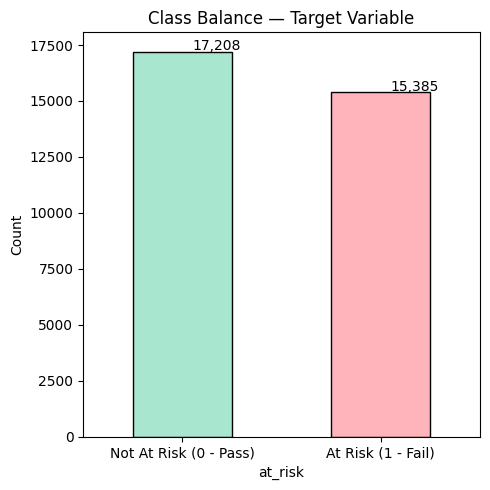

In [81]:
#Class Balance
plt.figure(figsize=(5, 5))
ax = df['at_risk'].value_counts().plot(
    kind='bar',
    color=['#A8E6CF', '#FFB3BA'],
    edgecolor='black'
)

ax.set_xticklabels([
    'Not At Risk (0 - Pass)',
    'At Risk (1 - Fail)'
], rotation=0)

ax.set_title('Class Balance — Target Variable')
ax.set_ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + 0.3, p.get_height() + 50))

plt.tight_layout()
plt.show()

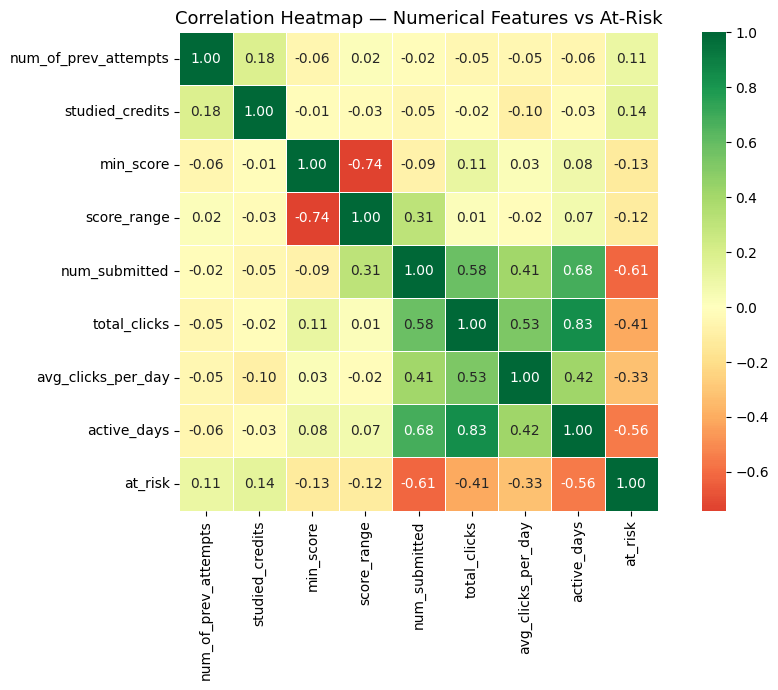

In [36]:
#correlation
corr_cols = ['num_of_prev_attempts', 'studied_credits', 'min_score',
             'score_range', 'num_submitted', 'total_clicks',
             'avg_clicks_per_day', 'active_days', 'at_risk']

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap — Numerical Features vs At-Risk', fontsize=13)
plt.tight_layout()
plt.show()

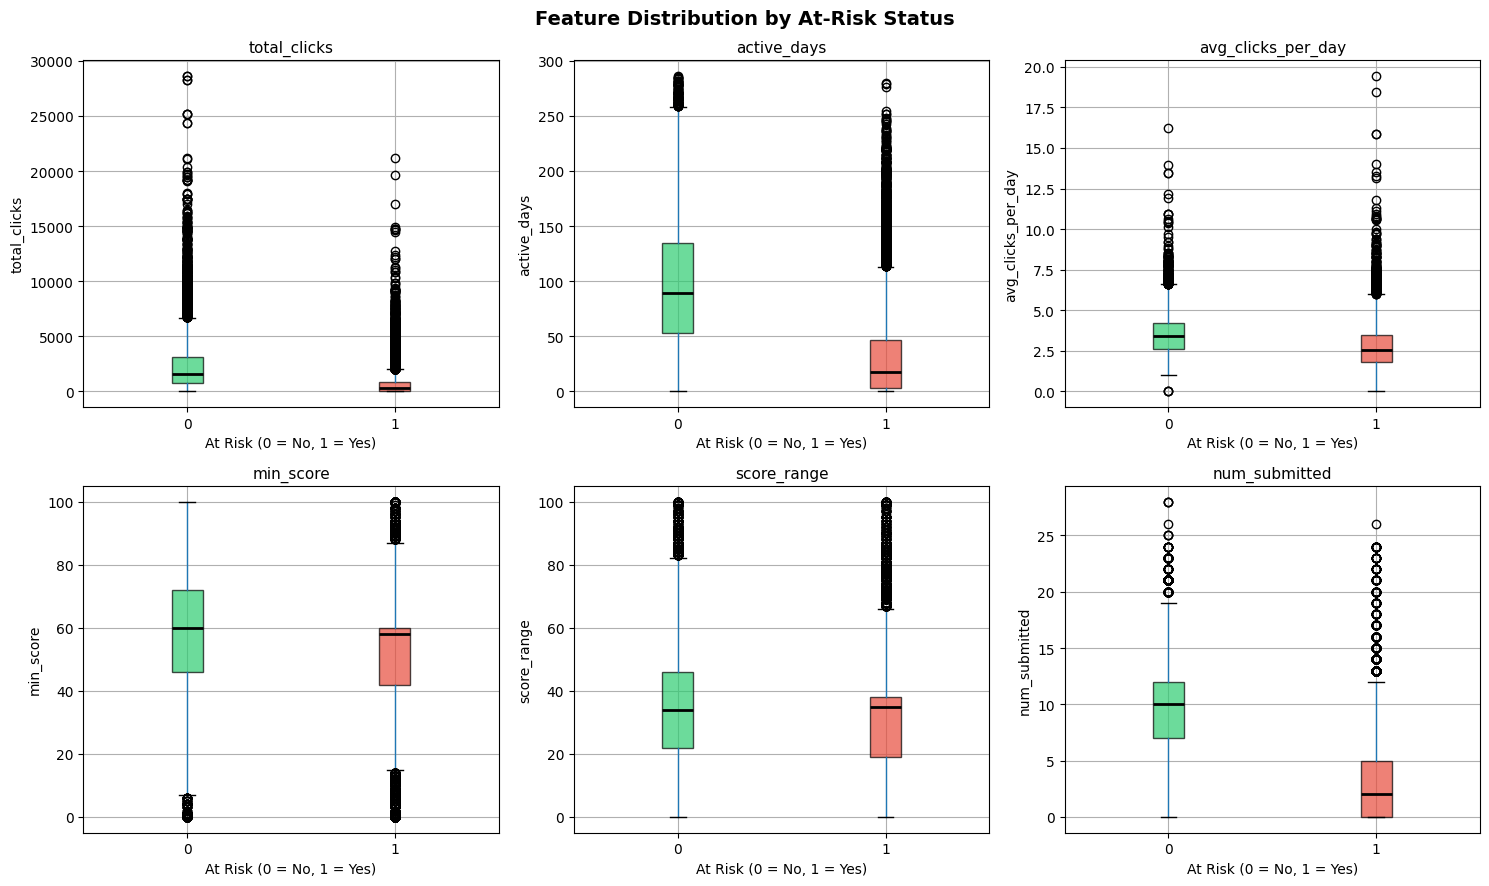

In [39]:
#Boxplots — key features split by at_risk
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

box_features = ['total_clicks', 'active_days', 'avg_clicks_per_day',
                'min_score', 'score_range', 'num_submitted']

colors = ['#2ecc71', '#e74c3c']

for ax, col in zip(axes.flatten(), box_features):
    df.boxplot(column=col, by='at_risk', ax=ax,
               patch_artist=True,
               boxprops=dict(color='black'),
               medianprops=dict(color='black', linewidth=2))

    # Color the boxes
    for patch, color in zip(ax.patches, colors * 10):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(col, fontsize=11)
    ax.set_xlabel('At Risk (0 = No, 1 = Yes)')
    ax.set_ylabel(col)

plt.suptitle('Feature Distribution by At-Risk Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
#Categorical features to be encoded
cat_cols = ['gender', 'region', 'imd_band', 'age_band', 'highest_education', 'disability']

In [41]:
# One-hot encode categorical features and prepare LR feature matrix & target
df_lr_encoded = pd.get_dummies(df_lr, columns=cat_cols, drop_first=True)

lr_features = ['num_of_prev_attempts_log', 'studied_credits', 'min_score',
               'score_range', 'num_submitted', 'total_clicks_log',
               'avg_clicks_per_day', 'active_days'] + \
              [c for c in df_lr_encoded.columns if any(c.startswith(cat) for cat in cat_cols)]

X_lr = df_lr_encoded[lr_features] # features
y_lr = df_lr_encoded['at_risk']  # target

In [43]:
# One-hot encode categorical features and prepare XGBoost feature matrix & target
df_xgb_encoded = pd.get_dummies(df_xgb, columns=cat_cols, drop_first=True)

xgb_features = ['num_of_prev_attempts', 'studied_credits', 'min_score',
                'score_range', 'num_submitted', 'total_clicks',
                'avg_clicks_per_day', 'active_days'] + \
               [c for c in df_xgb_encoded.columns if any(c.startswith(cat) for cat in cat_cols)]

X_xgb = df_xgb_encoded[xgb_features] # features
y_xgb = df_xgb_encoded['at_risk']    # target

In [44]:
# Check feature matrix shapes and target class distribution
print("LR feature matrix :", X_lr.shape)
print("XGB feature matrix :", X_xgb.shape)
print("Target (LR)        :", y_lr.value_counts().to_dict())

LR feature matrix : (32593, 37)
XGB feature matrix : (32593, 37)
Target (LR)        : {1: 17208, 0: 15385}


In [45]:
# LR version
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr,
    test_size=0.2,
    random_state=42,
    stratify=y_lr
)

#  XGB version
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y_xgb,
    test_size=0.2,
    random_state=42,
    stratify=y_xgb
)

# Scale LR version only
scaler = StandardScaler()
X_train_lr_sc = scaler.fit_transform(X_train_lr)
X_test_lr_sc  = scaler.transform(X_test_lr)

In [46]:
# Check train/test split sizes and class balance
print("LR  — Train:", X_train_lr_sc.shape, " Test:", X_test_lr_sc.shape)
print("XGB — Train:", X_train_xgb.shape,   " Test:", X_test_xgb.shape)
print("\nClass balance in LR train set:")
print(y_train_lr.value_counts(normalize=True).round(3))

LR  — Train: (26074, 37)  Test: (6519, 37)
XGB — Train: (26074, 37)  Test: (6519, 37)

Class balance in LR train set:
at_risk
1    0.528
0    0.472
Name: proportion, dtype: float64


In [47]:
# LogisticRegression Fit
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_lr_sc, y_train_lr)

# Predict
y_pred_lr = lr_model.predict(X_test_lr_sc)
y_prob_lr = lr_model.predict_proba(X_test_lr_sc)[:, 1]


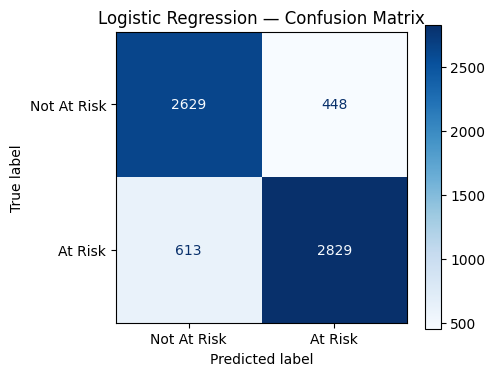

In [48]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_lr, y_pred_lr,
    display_labels=['Not At Risk', 'At Risk'],
    cmap='Blues', ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

In [50]:
# Classification Report
print()
print("Logistic Regression — Classification Report")
print()
print(classification_report(y_test_lr, y_pred_lr,
      target_names=['Not At Risk', 'At Risk']))


Logistic Regression — Classification Report

              precision    recall  f1-score   support

 Not At Risk       0.81      0.85      0.83      3077
     At Risk       0.86      0.82      0.84      3442

    accuracy                           0.84      6519
   macro avg       0.84      0.84      0.84      6519
weighted avg       0.84      0.84      0.84      6519



In [51]:
# Key Metrics
print(f"Accuracy  : {accuracy_score(y_test_lr, y_pred_lr):.4f}")
print(f"Precision : {precision_score(y_test_lr, y_pred_lr):.4f}")
print(f"Recall    : {recall_score(y_test_lr, y_pred_lr):.4f}")
print(f"F1 Score  : {f1_score(y_test_lr, y_pred_lr):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_lr, y_prob_lr):.4f}")

Accuracy  : 0.8372
Precision : 0.8633
Recall    : 0.8219
F1 Score  : 0.8421
ROC-AUC   : 0.9103


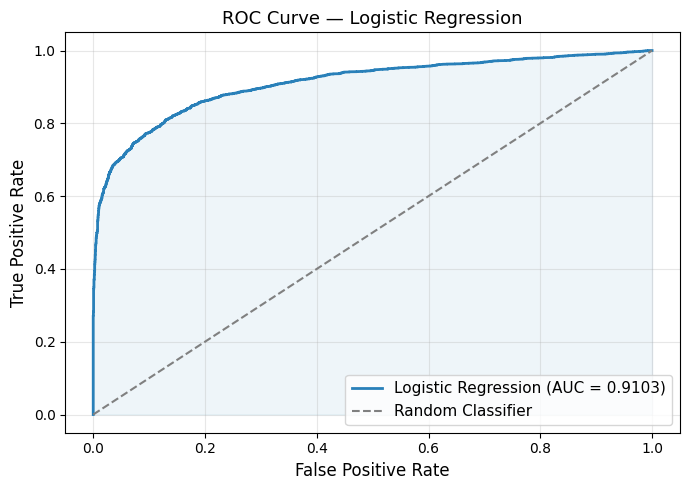

In [53]:
# Plot ROC curve and compute AUC for Logistic Regression
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test_lr, y_prob_lr)
auc_lr = roc_auc_score(y_test_lr, y_prob_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, color='#2980b9', lw=2,
         label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1.5,
         linestyle='--', label='Random Classifier')
plt.fill_between(fpr_lr, tpr_lr, alpha=0.08, color='#2980b9')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Logistic Regression', fontsize=13)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
#AUC Score
print(f"AUC Score : {auc_lr:.4f}")

AUC Score : 0.9103


In [62]:
# 5-Fold CV
cv_scores = cross_val_score(lr_model, X_train_lr_sc, y_train_lr,
                             cv=5, scoring='roc_auc')
print(f"5-Fold CV AUC : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


5-Fold CV AUC : 0.9056 ± 0.0038


In [65]:
# Train XGBoost model and generate predictions
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_xgb, y_train_xgb)

# Predictions and probabilities
y_pred_xgb = xgb_model.predict(X_test_xgb)
y_prob_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

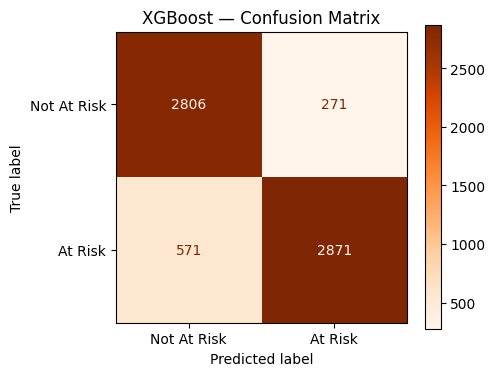

In [66]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_xgb, y_pred_xgb,
    display_labels=['Not At Risk', 'At Risk'],
    cmap='Oranges', ax=ax
)
ax.set_title('XGBoost — Confusion Matrix')
plt.tight_layout()
plt.show()

In [67]:
# Classification Report
print("\nXGBoost — Classification Report\n")
print(classification_report(y_test_xgb, y_pred_xgb,
      target_names=['Not At Risk', 'At Risk']))



XGBoost — Classification Report

              precision    recall  f1-score   support

 Not At Risk       0.83      0.91      0.87      3077
     At Risk       0.91      0.83      0.87      3442

    accuracy                           0.87      6519
   macro avg       0.87      0.87      0.87      6519
weighted avg       0.87      0.87      0.87      6519



In [68]:
# Key Metrics
print(f"Accuracy  : {accuracy_score(y_test_xgb, y_pred_xgb):.4f}")
print(f"Precision : {precision_score(y_test_xgb, y_pred_xgb):.4f}")
print(f"Recall    : {recall_score(y_test_xgb, y_pred_xgb):.4f}")
print(f"F1 Score  : {f1_score(y_test_xgb, y_pred_xgb):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_xgb, y_prob_xgb):.4f}")

Accuracy  : 0.8708
Precision : 0.9137
Recall    : 0.8341
F1 Score  : 0.8721
ROC-AUC   : 0.9500


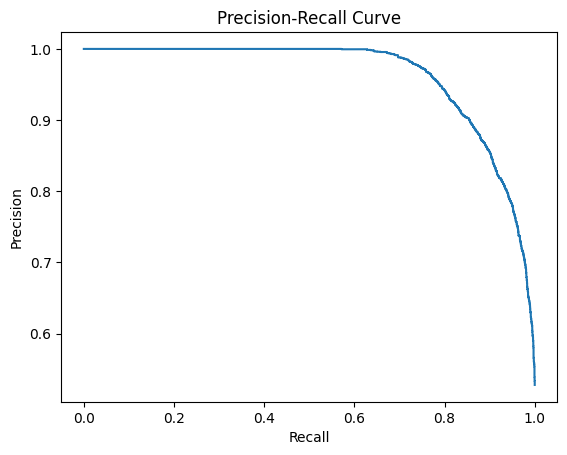

In [75]:
# Plot Precision-Recall curve for XGBoost
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test_xgb, y_prob_xgb)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [69]:
# Compare performance metrics for Logistic Regression vs XGBoost
results = {
    'Model'    : ['Logistic Regression', 'XGBoost'],
    'Accuracy' : [accuracy_score(y_test_lr, y_pred_lr),
                  accuracy_score(y_test_xgb, y_pred_xgb)],
    'Precision': [precision_score(y_test_lr, y_pred_lr),
                  precision_score(y_test_xgb, y_pred_xgb)],
    'Recall'   : [recall_score(y_test_lr, y_pred_lr),
                  recall_score(y_test_xgb, y_pred_xgb)],
    'F1'       : [f1_score(y_test_lr, y_pred_lr),
                  f1_score(y_test_xgb, y_pred_xgb)],
    'ROC-AUC'  : [roc_auc_score(y_test_lr, y_prob_lr),
                  roc_auc_score(y_test_xgb, y_prob_xgb)],
}

pd.DataFrame(results).set_index('Model').round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8372,0.8633,0.8219,0.8421,0.9103
XGBoost,0.8708,0.9137,0.8341,0.8721,0.9500
